In [1]:
import matplotlib.pyplot as plt
from datetime import datetime
from lppls import lppls, data_loader
import numpy as np
import pandas as pd
from datetime import datetime as dt
from pathlib import Path

In [30]:
df = pd.read_excel("your_data.xlsx") #initial format
df.head()

,t,p,d
0,1735920009745,97658,2025-01-03
1,1735920022707,97661,2025-01-03
2,1735920028288,97697,2025-01-03
3,1735920028289,97697,2025-01-03
4,1735920028289,97706,2025-01-03


In [32]:
#convert to datetime
df['t'] = pd.to_numeric(df['t'])
df = df.dropna(subset=['t'])
df['t'] = pd.to_datetime(df['t'], unit='ms')
df['t'] = df['t'].astype('str')

In [33]:
df = df.iloc[::-1].reset_index(drop=True)
df 

,t,p,d
0,2024-11-20 01:20:44.828,91884,2024-11-20
1,2024-11-20 01:20:40.799,91864,2024-11-20
2,2024-11-20 01:20:40.788,91860,2024-11-20
3,2024-11-20 01:20:28.515,91859,2024-11-20
4,2024-11-20 01:20:28.473,91859,2024-11-20
...,...,...,...
482606,2025-01-03 16:00:28.289,97706,2025-01-03
482607,2025-01-03 16:00:28.289,97697,2025-01-03
482608,2025-01-03 16:00:28.288,97697,2025-01-03
482609,2025-01-03 16:00:22.707,97661,2025-01-03


In [34]:
filepath = Path("your_data.csv") #save in an actual datetime format

df.to_csv(filepath)

In [24]:
df['t'] = df['t'].astype(str).str[:13]  # Keep only the first n characters: 13 = %HH - hour
df

In [16]:
df_avg = df.groupby('t', as_index=False)['p'].mean() #hourly mean
df_avg['p'] = df_avg['p'].round(0)
df_avg

,t,p
0,2024-10-29 16,72617.0
1,2024-10-29 17,72836.0
2,2024-11-01 16,69985.0
3,2024-11-02 14,69172.0
4,2024-11-04 18,67773.0
...,...,...
260,2025-01-22 16,103731.0
261,2025-01-23 15,103948.0
262,2025-01-23 17,105289.0
263,2025-01-23 21,102884.0


In [17]:
filepath = Path("hourly_data.csv") 
df_avg.to_csv(filepath)

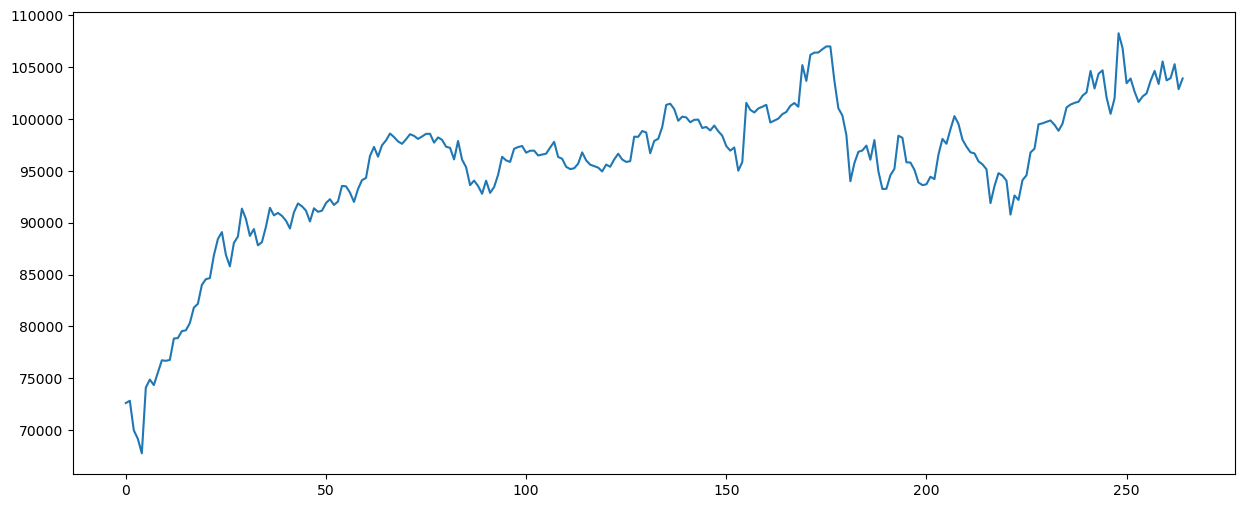

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(df_avg['p'].values)

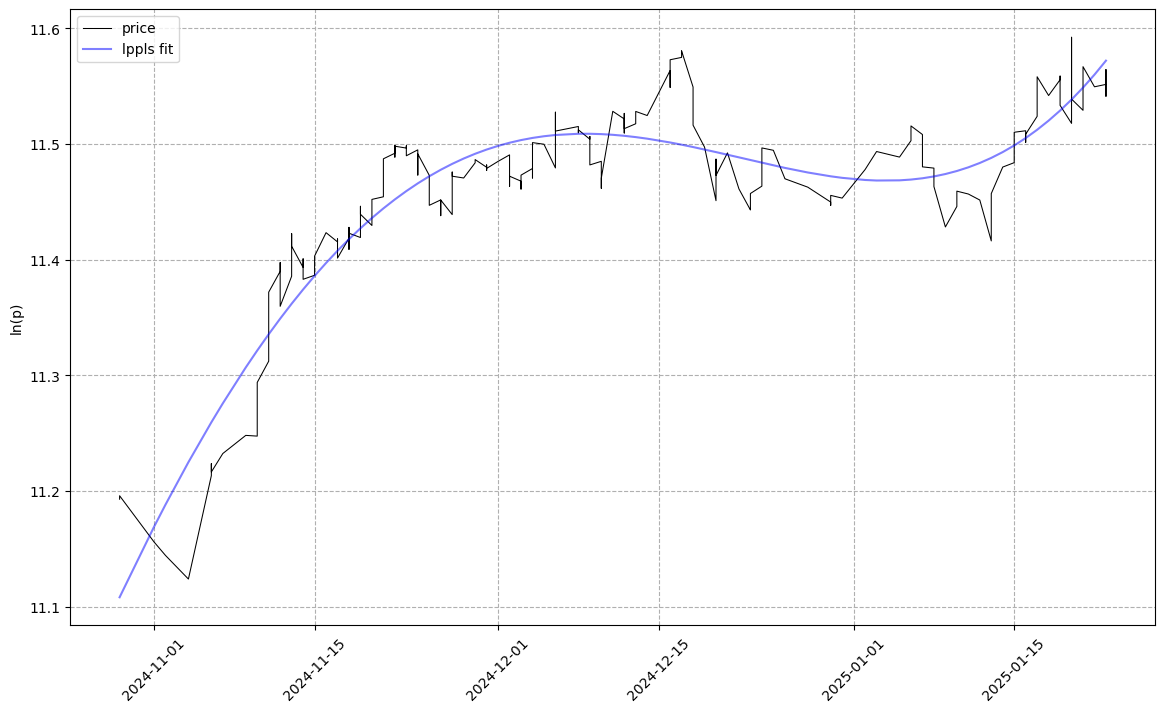

In [11]:
from lppls import lppls, data_loader
import numpy as np
import pandas as pd
from datetime import datetime as dt
%matplotlib inline

time = [
    pd.Timestamp.toordinal(dt.strptime(t1, '%Y-%m-%d %H')) for t1 in df_avg['t']
]

price = np.log((df_avg['p']).values)

observations = np.array([time, price])

# set the max number for searches to perform before giving-up

MAX_SEARCHES = 25

lppls_model = lppls.LPPLS(observations=observations)

tc, m, w, a, b, c, c1, c2, O, D = lppls_model.fit(MAX_SEARCHES)

lppls_model.plot_fit()

100%|████████████████████████████████████████████████████████████████████████████████| 247/247 [00:07<00:00, 34.08it/s]


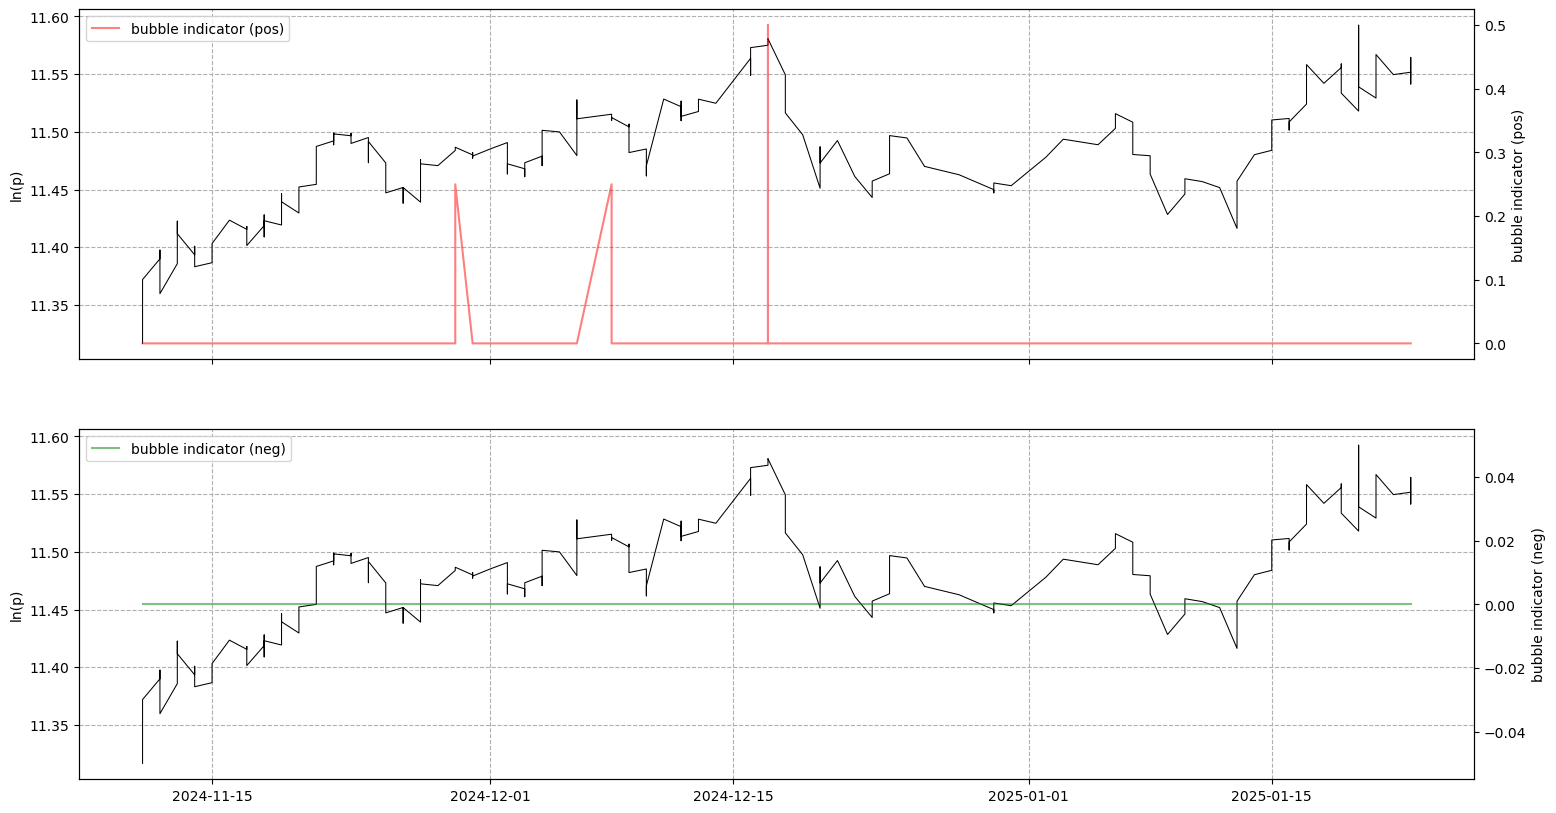

In [12]:
res = lppls_model.mp_compute_nested_fits(
    workers=10,
    window_size=19, 
    smallest_window_size=10, 
    outer_increment=1, 
    inner_increment=2, 
     max_searches=25)

lppls_model.plot_confidence_indicators(res)

In [13]:
res_df = lppls_model.compute_indicators(res)
res_df

,time,price,pos_conf,neg_conf,_fits
0,739201.0,11.316679,0.0,0.0,"[{'tc': 739189.1597420597, 'm': 0.909301127038..."
1,739201.0,11.338691,0.0,0.0,"[{'tc': 739189.2544112976, 'm': 0.019541341476..."
2,739201.0,11.345217,0.0,0.0,"[{'tc': 739207.9454472037, 'm': 0.578718917040..."
3,739201.0,11.346458,0.0,0.0,"[{'tc': 739273.1447236438, 'm': -0.92238205680..."
4,739201.0,11.371995,0.0,0.0,"[{'tc': 739202.0277169708, 'm': 1.596399172786..."
...,...,...,...,...,...
242,739273.0,11.549556,0.0,0.0,"[{'tc': 739279.1629415248, 'm': 0.286279548813..."
243,739274.0,11.551646,0.0,0.0,"[{'tc': 739273.4465937831, 'm': 0.732692624256..."
244,739274.0,11.564464,0.0,0.0,"[{'tc': 739274.014471686, 'm': 0.9636012947611..."
245,739274.0,11.541357,0.0,0.0,"[{'tc': 739273.81147963, 'm': 0.78566512461551..."


In [14]:
filepath = Path("your_path//lppl_hifr.csv") #save hourly results

res_df.to_csv(filepath)